In [1]:
import py_ttcross as ttc
from py_ttcross.quantic_tt_cross.interpolators_1D import (
    greedy_one_dim_func_interpolator,
    ttrc_one_dim_func_interpolator,
)
import numpy as np
import numba
import matplotlib.pyplot as plt

In [ ]:
def func(x):
    return np.abs(x * np.sin(x))


def func2(x):
    B = 2 ** (-30)
    return np.cos(x / B) * np.cos(x / (4 * np.sqrt(5) * B)) * np.exp(-(x**2)) + 2 * np.exp(-x)

In [ ]:
interval = [-3, 3]
d = 15

test_interpolator = greedy_one_dim_func_interpolator(
    func=func,
    interval=interval,
    d=d,
    complex_function=False,
    max_bond=3,
    pivot_finder_tol=1e-8,
    sweeps=5,
)

In [16]:
test_interpolator.interpolate()

Function not compiled with numba. Using non-compiled version.
Initialization succesfully done after time: 0.0004334449768066406 seconds and 1 tries.
Sweep 1
Sweep 2
Sweep 3


<>:12: SyntaxWarning: invalid escape sequence '\c'
<>:12: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_12229/3486540808.py:12: SyntaxWarning: invalid escape sequence '\c'
  plt.title("Interpolation of $f(x) = \cos(x / 2^{-30})\cos(x / (4\sqrt{5}2^{-30}))e^{-x^2} + 2e^{-x}$")


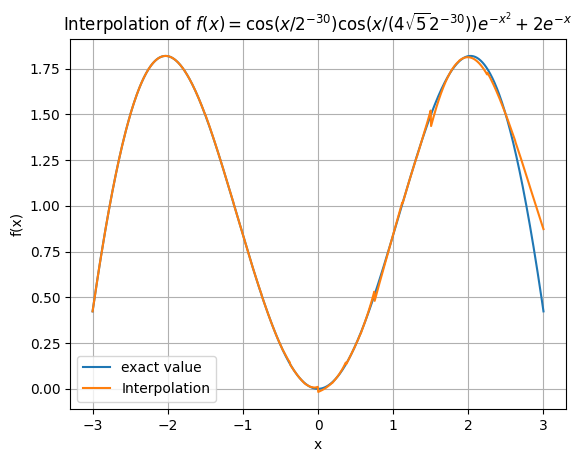

In [17]:
x = np.linspace(interval[0], interval[1], 1000)

y = [func(x_i) for x_i in x]

interpolation = np.array([test_interpolator.eval(x_i) for x_i in x])

plt.plot(x, y, label="exact value")
plt.plot(x, interpolation, label="Interpolation")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Interpolation of $f(x) = \cos(x / 2^{-30})\cos(x / (4\sqrt{5}2^{-30}))e^{-x^2} + 2e^{-x}$")
plt.legend()
plt.grid(True)
plt.show()